

 𝐀 𝐇𝐲𝐛𝐫𝐢𝐝 𝐀𝐈 𝐀𝐩𝐩𝐫𝐨𝐚𝐜𝐡 𝐟𝐨𝐫 𝐄𝐚𝐫𝐥𝐲 𝐃𝐞𝐭𝐞𝐜𝐭𝐢𝐨𝐧 𝐚𝐧𝐝 𝐑𝐢𝐬𝐤 𝐒𝐭𝐫𝐚𝐭𝐢𝐟𝐢𝐜𝐚𝐭𝐢𝐨𝐧 𝐨𝐟 𝐂𝐡𝐫𝐨𝐧𝐢𝐜 𝐊𝐢𝐝𝐧𝐞𝐲 𝐃𝐢𝐬𝐞𝐚𝐬𝐞 𝐔𝐬𝐢𝐧𝐠 𝐒𝐮𝐩𝐞𝐫𝐯𝐢𝐬𝐞𝐝 𝐚𝐧𝐝 𝐔𝐧𝐬𝐮𝐩𝐞𝐫𝐯𝐢𝐬𝐞𝐝 𝐋𝐞𝐚𝐫𝐧𝐢𝐧𝐠

Chronic Kidney Disease (CKD) is a progressive condition that often remains asymptomatic until reaching advanced stages. Early detection and accurate classification are essential for timely intervention and improved clinical outcomes. This notebook presents a **hybrid artificial intelligence approach** that integrates both **supervised** and **unsupervised learning techniques** to effectively detect and analyze CKD cases using real-world medical data.

### Dataset
The dataset used in this study is obtained from [Kaggle: Chronic Kidney Disease Dataset](https://www.kaggle.com/datasets/mansoordaku/ckdisease). It contains 400 instances and 26 attributes related to patient demographics, medical test results, and health indicators.

---

### This Jupyter Notebook Covers the Following Key Steps:

- 📊 **Exploratory Data Analysis (EDA)**  
  Visualizations including count plots, violin plots, KDE distributions, and scatter plots to understand data trends and feature relationships.

- 🧹 **Data Preprocessing**  
  Handling missing values, feature scaling, dimensionality reduction using PCA, and data splitting.

- 🔠 **Feature Encoding**  
  Applying `LabelEncoder` to convert categorical variables into numeric form.

- 🤖 **Model Building and Evaluation**  
  Implementation of multiple machine learning models including:
  
  - **K-Nearest Neighbors (KNN)**
  - **Decision Tree Classifier**
  - **Random Forest Classifier**
  - **AdaBoost Classifier**
  - **Stochastic Gradient Boosting**
  
  Each model is trained and evaluated using metrics like accuracy, confusion matrix, and classification report. Hyperparameter tuning is performed using `GridSearchCV` where applicable, and cross-validation ensures robustness.



This work aims to demonstrate the power of combining machine learning techniques for medical diagnosis and risk stratification. The results provide insights into which models perform best for CKD prediction and highlight important features contributing to early disease detection.




In [19]:
# necessary imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
%matplotlib inline
pd.set_option('display.max_columns', 26)

In [20]:
# loading data

df= pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121,36.0,1.2,130,3.3,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,110,18.0,0.8,145,4.9,11.3,38,6000,4.3,no,no,no,good,no,no,ckd
2,2,62,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423,53.0,1.8,150,6.1,9.6,31,7500,4.2,no,yes,no,poor,no,yes,ckd
3,3,48,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117,56.0,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106,26.0,1.4,121,3.5,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [21]:
df.shape

(400, 26)

In [4]:
# dropping id column
df.drop('id', axis = 1, inplace = True)

In [24]:
# rename column names to make it more user-friendly

df.columns = ['id','age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'anemia', 'class']

In [25]:
df.head()

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,0,48,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121,36.0,1.2,130,3.3,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,110,18.0,0.8,145,4.9,11.3,38,6000,4.3,no,no,no,good,no,no,ckd
2,2,62,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423,53.0,1.8,150,6.1,9.6,31,7500,4.2,no,yes,no,poor,no,yes,ckd
3,3,48,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117,56.0,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106,26.0,1.4,121,3.5,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [26]:
df.describe()

,id,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,400.000000,400.000000,398.000000,400.000000,400.000000,399.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,51.592500,76.005025,1.017238,1.055025,0.498747,149.922500,57.298000,3.056625,140.130000,4.887450,12.365000,39.820000,8494.152500,4.868275
std,115.614301,17.144132,13.922056,0.005735,1.310062,1.051141,79.289429,49.812604,5.632821,9.607229,2.965212,2.921371,10.324441,4527.314759,1.109608
min,0.000000,2.000000,40.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,104.000000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,100.000000,27.000000,0.900000,135.000000,3.900000,10.200000,33.000000,6600.000000,4.200000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,123.000000,42.000000,1.300000,140.000000,4.500000,12.400000,40.500000,8000.000000,4.900000
75%,299.250000,65.000000,80.000000,1.020000,2.000000,0.500000,169.250000,66.000000,2.800000,145.000000,5.000000,14.800000,46.000000,9700.000000,5.600000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,190.000000,47.000000,17.800000,90.000000,80000.000000,9.400000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      400 non-null    int64  
 2   blood_pressure           398 non-null    float64
 3   specific_gravity         400 non-null    float64
 4   albumin                  400 non-null    float64
 5   sugar                    399 non-null    float64
 6   red_blood_cells          400 non-null    object 
 7   pus_cell                 400 non-null    object 
 8   pus_cell_clumps          400 non-null    object 
 9   bacteria                 400 non-null    object 
 10  blood_glucose_random     400 non-null    int64  
 11  blood_urea               400 non-null    float64
 12  serum_creatinine         400 non-null    float64
 13  sodium                   400 non-null    int64  
 14  potassium                4


#As we can see that 'packed_cell_volume', 'white_blood_cell_count' and 'red_blood_cell_count' are object type. We need to change them to a numerical dtype.

In [28]:
# converting the necessary columns to numerical type

df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       400 non-null    int64  
 1   age                      400 non-null    int64  
 2   blood_pressure           398 non-null    float64
 3   specific_gravity         400 non-null    float64
 4   albumin                  400 non-null    float64
 5   sugar                    399 non-null    float64
 6   red_blood_cells          400 non-null    object 
 7   pus_cell                 400 non-null    object 
 8   pus_cell_clumps          400 non-null    object 
 9   bacteria                 400 non-null    object 
 10  blood_glucose_random     400 non-null    int64  
 11  blood_urea               400 non-null    float64
 12  serum_creatinine         400 non-null    float64
 13  sodium                   400 non-null    int64  
 14  potassium                4

In [30]:
# Extracting categorical and numerical columns

cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [31]:
# looking at unique values in categorical columns

for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has ['normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal'] values

pus_cell_clumps has ['notpresent' 'present'] values

bacteria has ['notpresent' 'present'] values

hypertension has ['yes' 'no'] values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes'] values

coronary_artery_disease has ['no' 'yes' '\tno'] values

appetite has ['good' 'poor'] values

peda_edema has ['no' 'yes'] values

anemia has ['no' 'yes'] values

class has ['ckd' 'ckd\t' 'notckd'] values



In [32]:
#There is some ambugity present in the columns we have to remove that.

In [14]:
# replace incorrect values

df['diabetes_mellitus'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'},inplace=True)

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value='no')

df['class'] = df['class'].replace(to_replace = {'ckd\t': 'ckd', 'notckd': 'not ckd'})

In [33]:
df['class'] = df['class'].map({'ckd': 0, 'not ckd': 1})
df['class'] = pd.to_numeric(df['class'], errors='coerce')

In [34]:
cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class']

for col in cols:
    print(f"{col} has {df[col].unique()} values\n")

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes'] values

coronary_artery_disease has ['no' 'yes' '\tno'] values

class has [ 0. nan] values



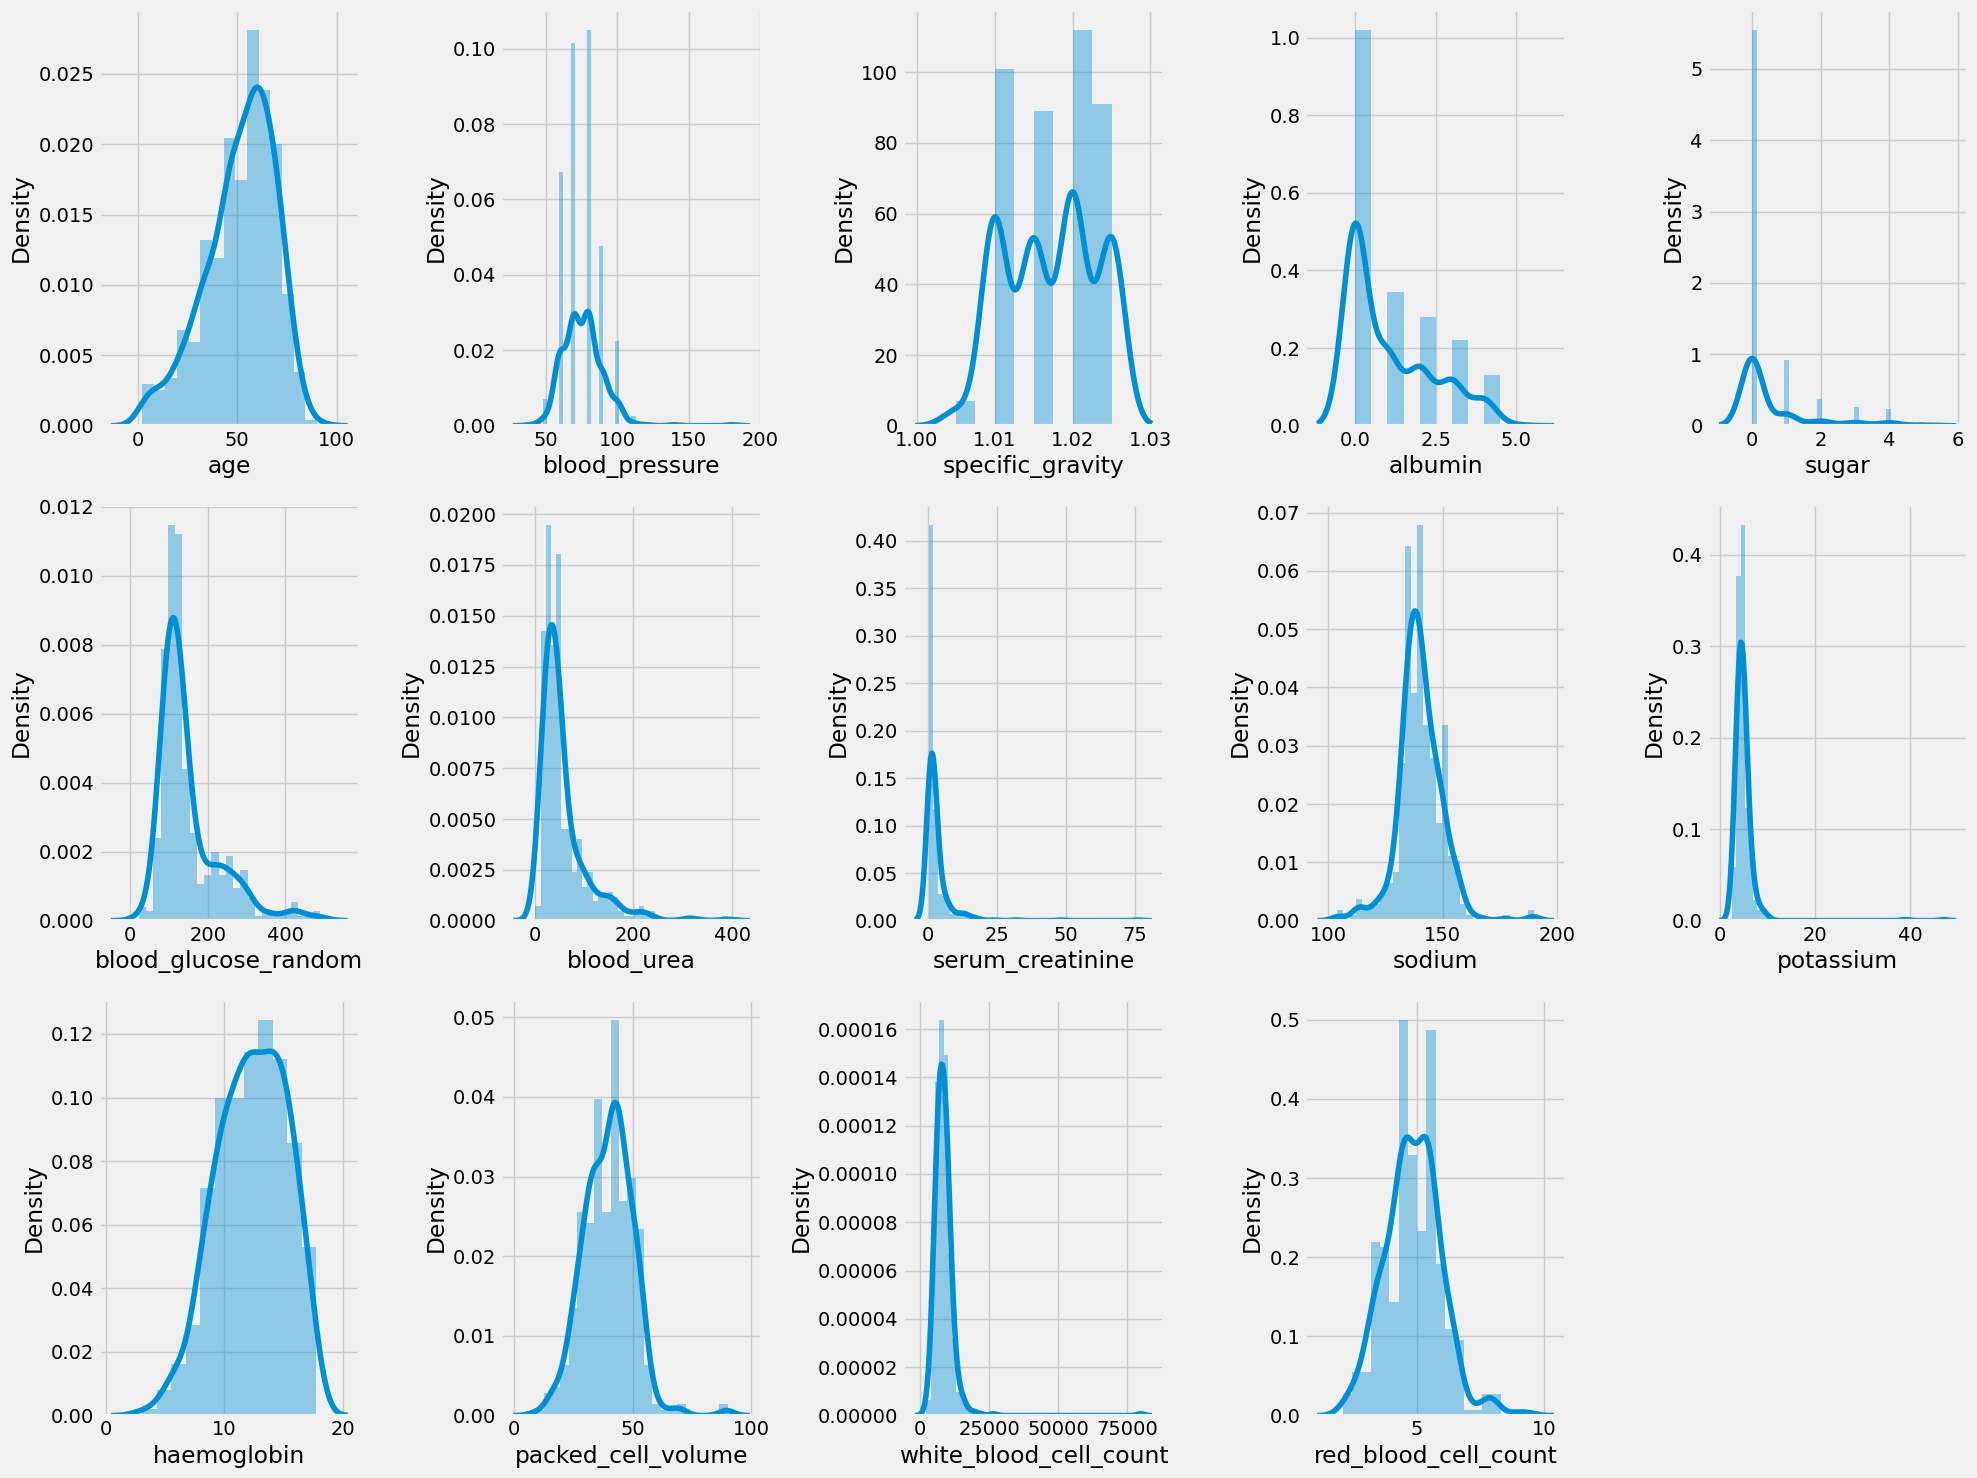

In [17]:
# checking numerical features distribution

plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()

#Skewness is present in some of the columns.

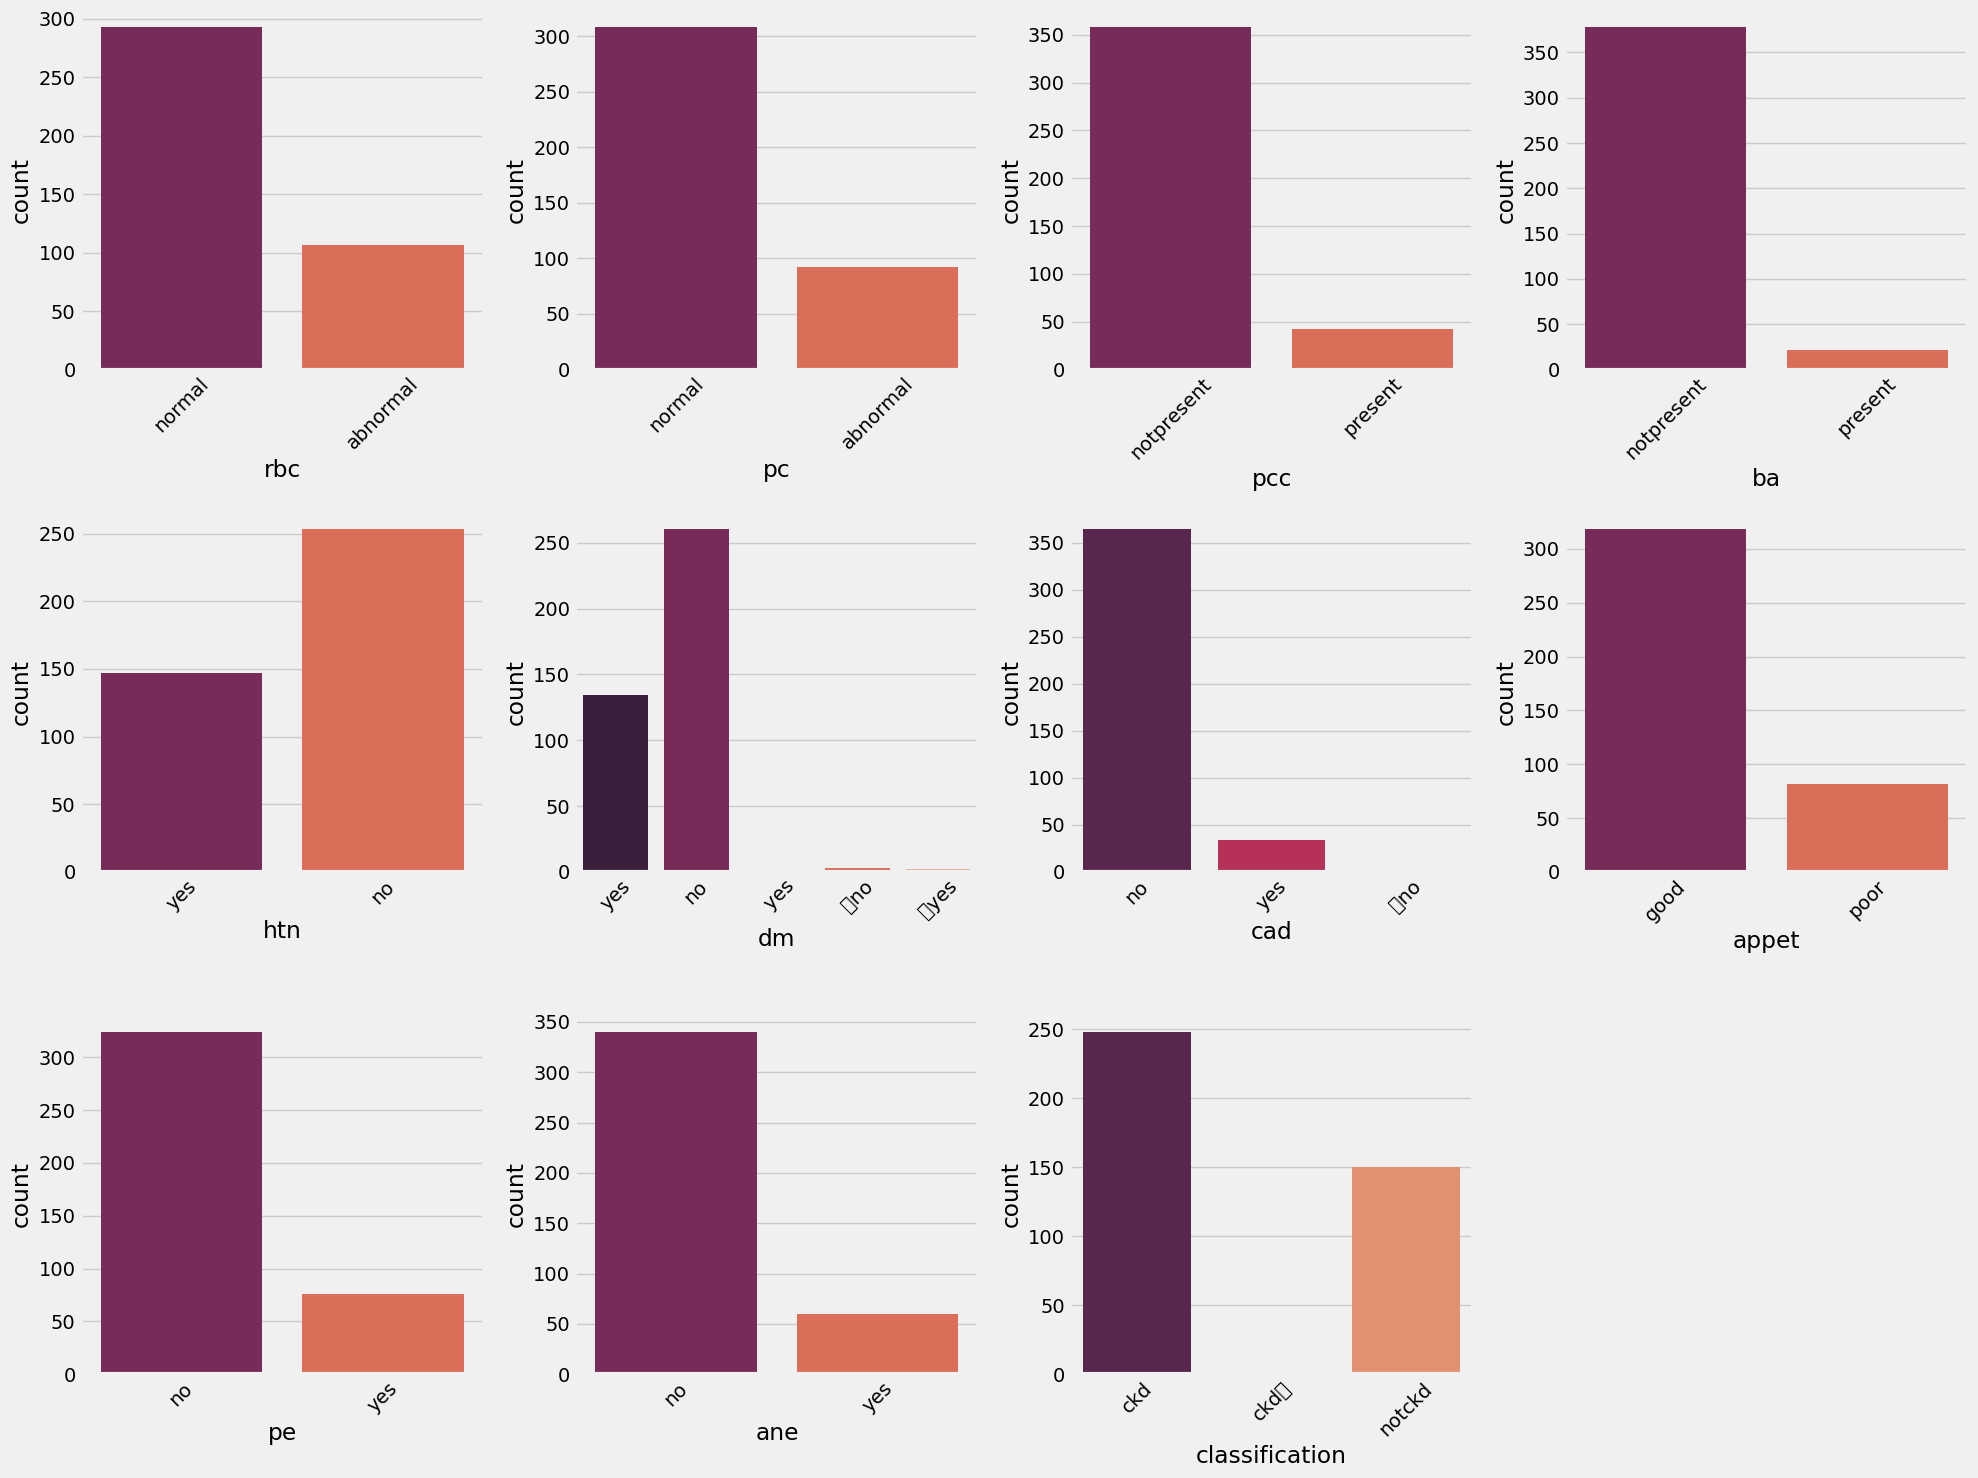

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Read dataset
df = pd.read_csv('kidney_disease.csv')

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Plotting
plt.figure(figsize=(20, 15))
plotnumber = 1

for column in cat_cols:
    if plotnumber <= 11:
        ax = plt.subplot(3, 4, plotnumber)
        sns.countplot(x=column, data=df, palette='rocket')
        plt.xlabel(column)
        plt.xticks(rotation=45)
        
    plotnumber += 1

plt.tight_layout()
plt.show()


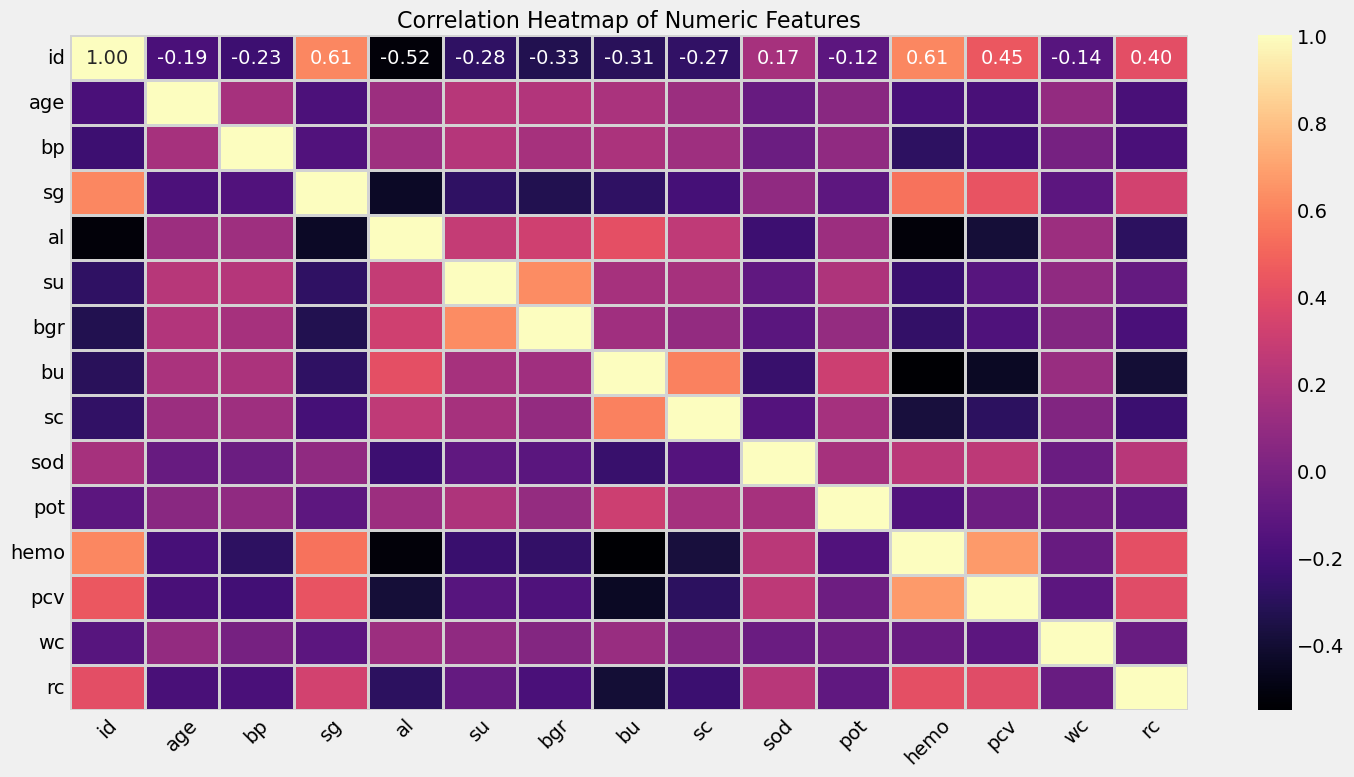

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv('kidney_disease.csv')

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include='number')

# Plot the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    linewidths=2,
    linecolor='lightgrey',
    cmap='magma',  # You can use 'coolwarm', 'viridis', 'plasma', 'rocket', etc.
    fmt='.2f',     # Format for correlation values
    cbar=True      # Colorbar on the right
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [31]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [ ]:

#Exploratory Data Analysis (EDA)

In [42]:


# Clean the entire DataFrame by stripping whitespace from string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Plotting function - Count plot
def count(col):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="classification")
    plt.title(f"Count of {col} by Classification")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Violin plot
def violin(col):
    fig = px.violin(df, y=col, x="classification", color="classification", box=True, template='plotly_dark')
    return fig.show()

# KDE plot
def kde(col):
    grid = sns.FacetGrid(df, hue="classification", height=6, aspect=2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

# Scatter plot
def scatter(col1, col2):
    fig = px.scatter(df, x=col1, y=col2, color="classification", template='plotly_dark')
    return fig.show()


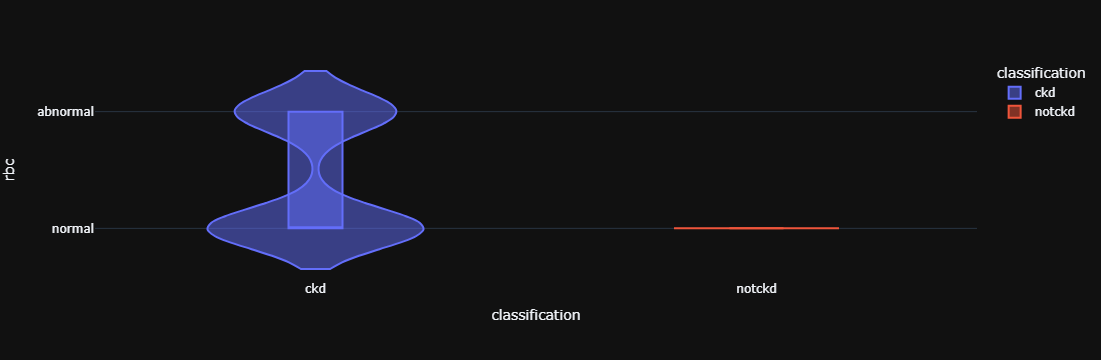

In [43]:
violin('rbc') #red_blood_cell_count


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("kidney_disease.csv")

# Clean the entire DataFrame by stripping whitespace from string columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Plotting function
def count(col):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="classification")
    plt.title(f"Count of {col} by Classification")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


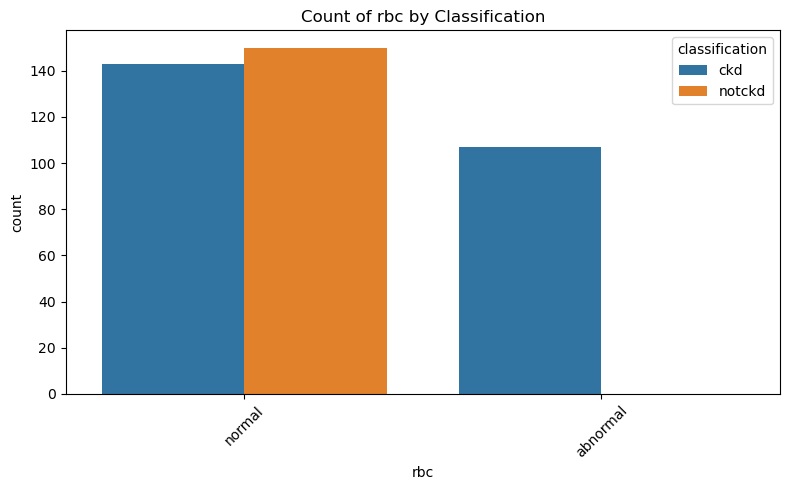

In [15]:
count('rbc')

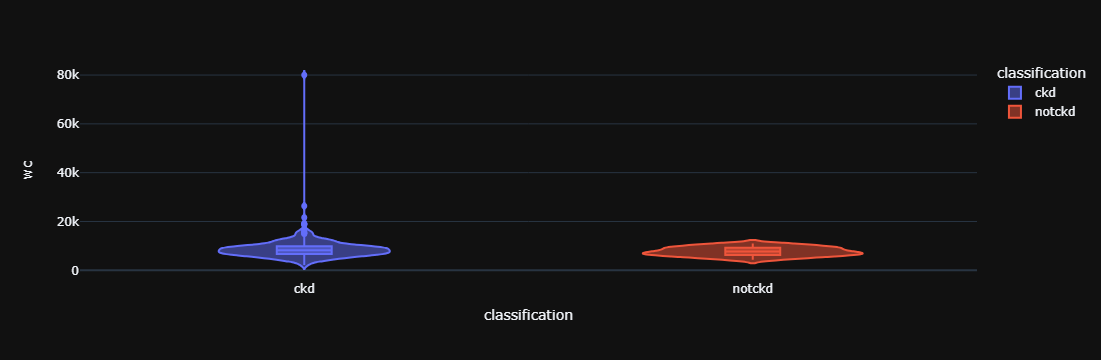

In [44]:
violin('wc') #white_blood_cell_count


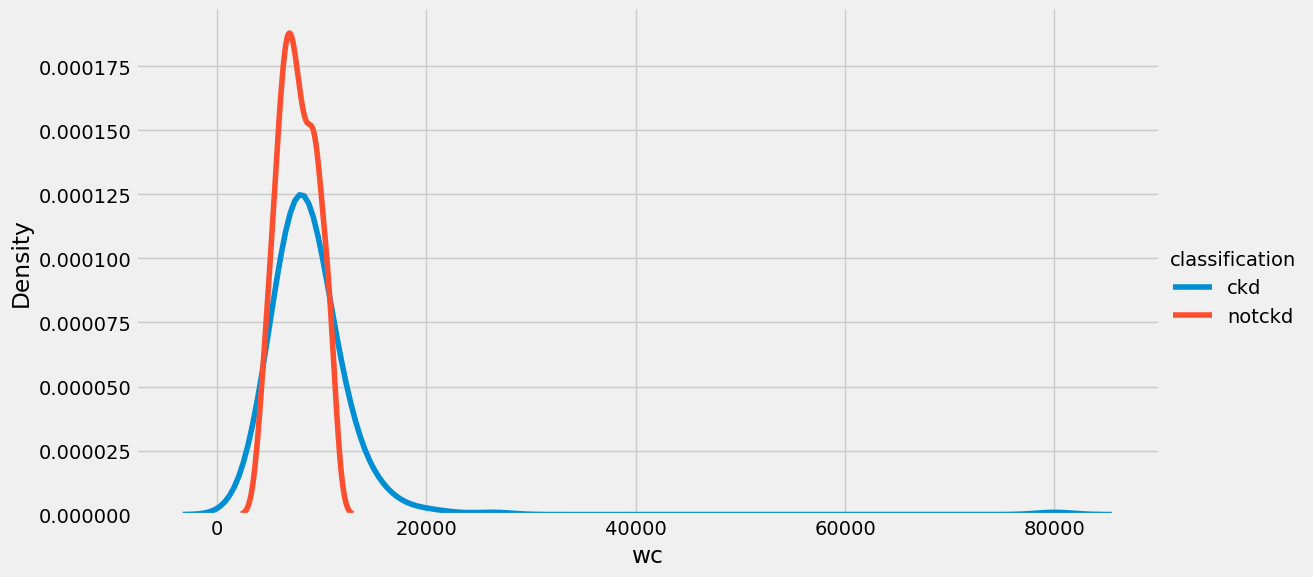

In [45]:
kde('wc') #white_blood_cell_count

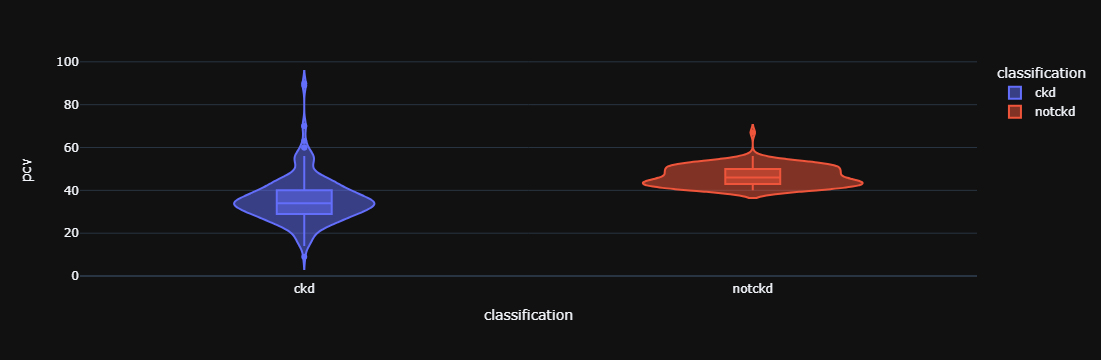

In [46]:
violin('pcv') #'packed_cell_volume

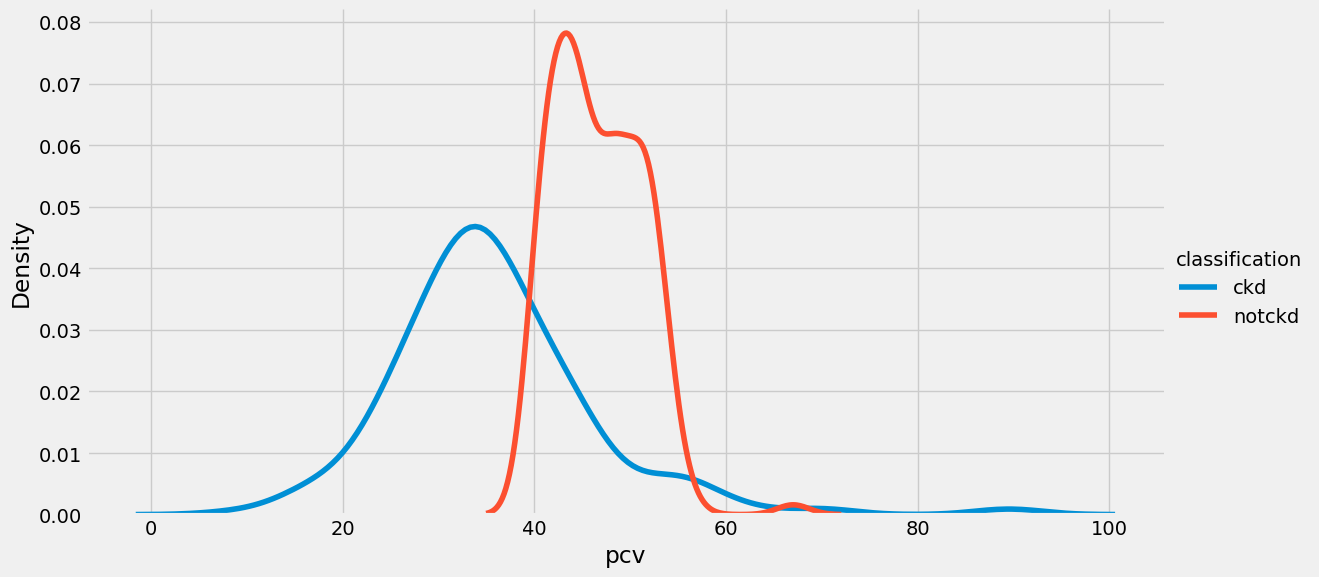

In [47]:
#packed_cell_volume
kde('pcv')

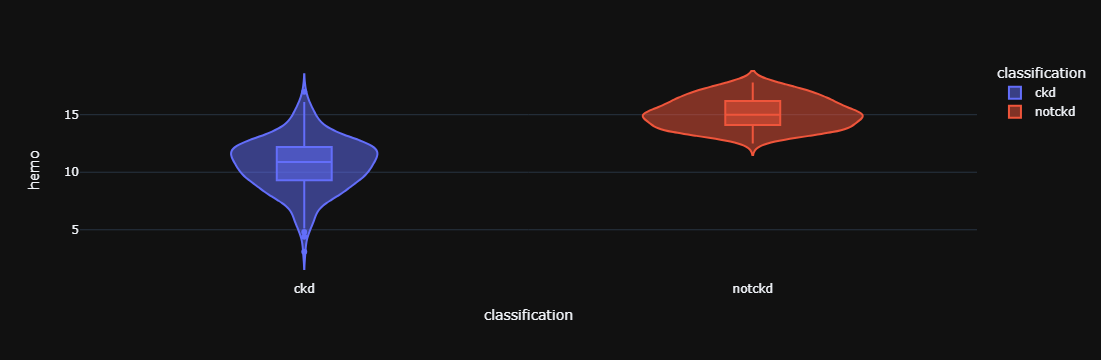

In [48]:
#haemoglobin
violin('hemo')

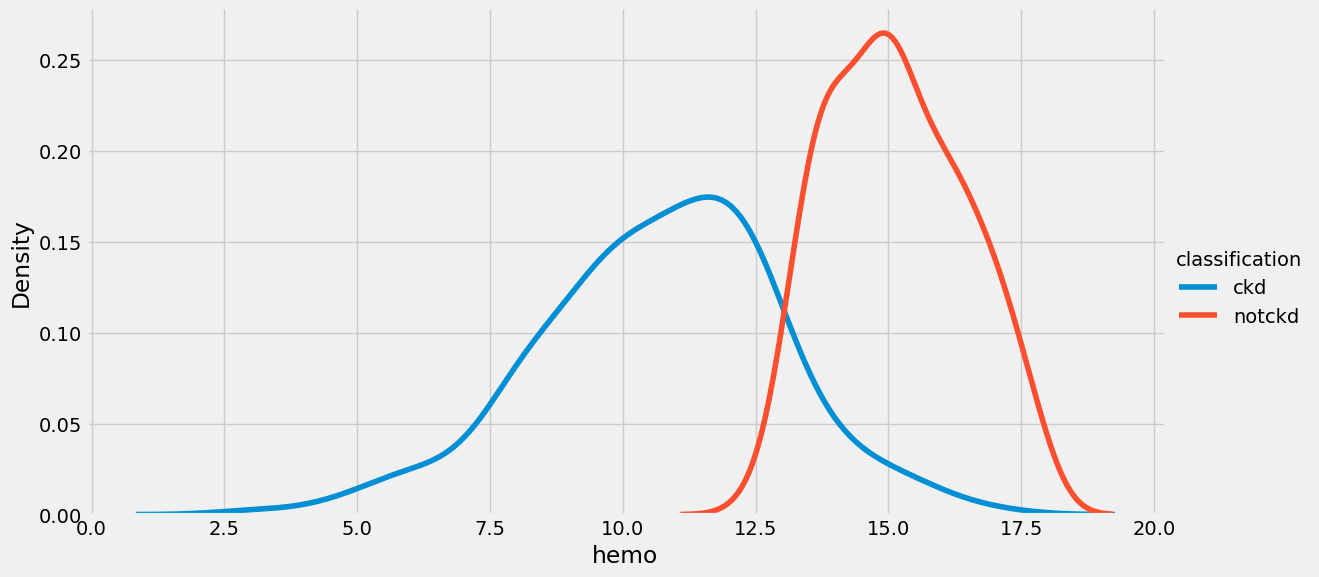

In [49]:
#haemoglobin
kde('hemo')


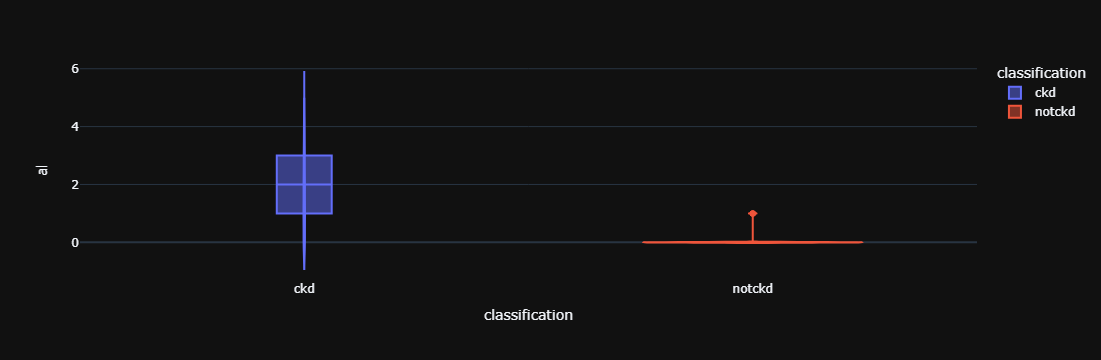

In [50]:
#albumin
violin('al')

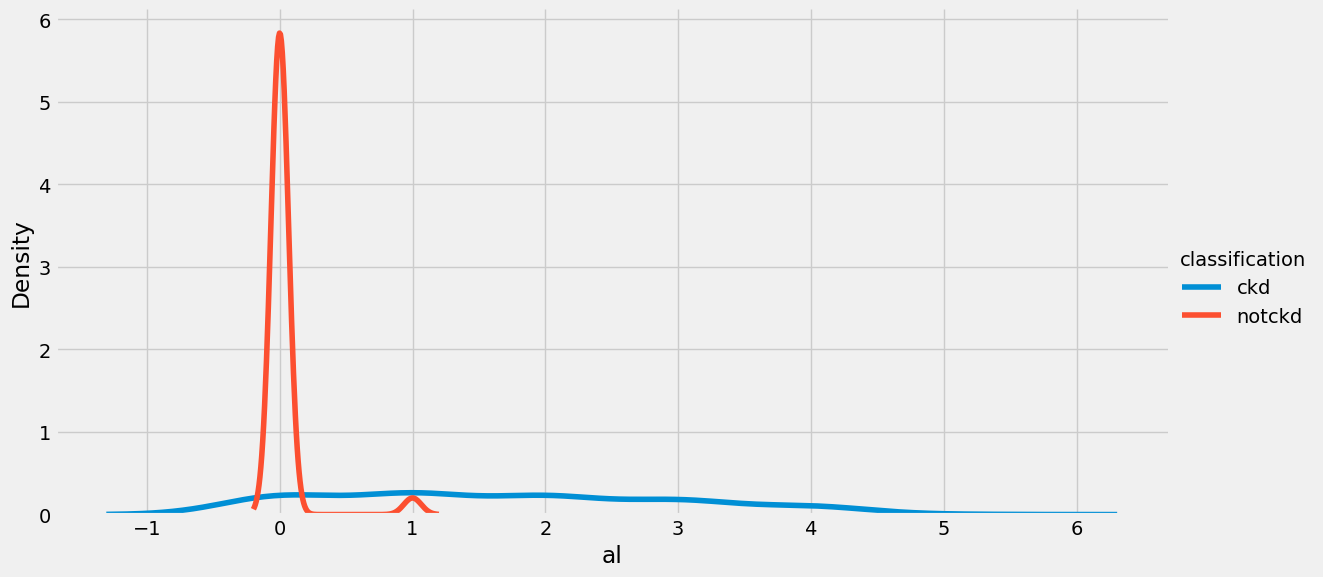

In [51]:
#kde('albumin')
kde('al')

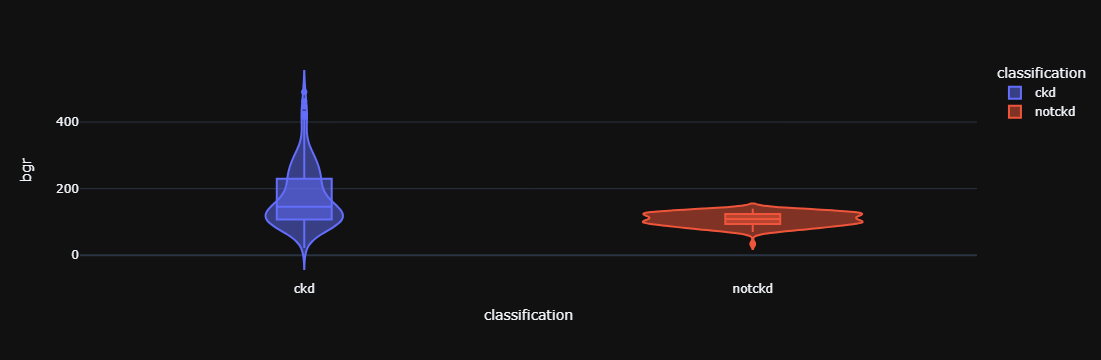

In [52]:
#blood_glucose_random
violin('bgr')

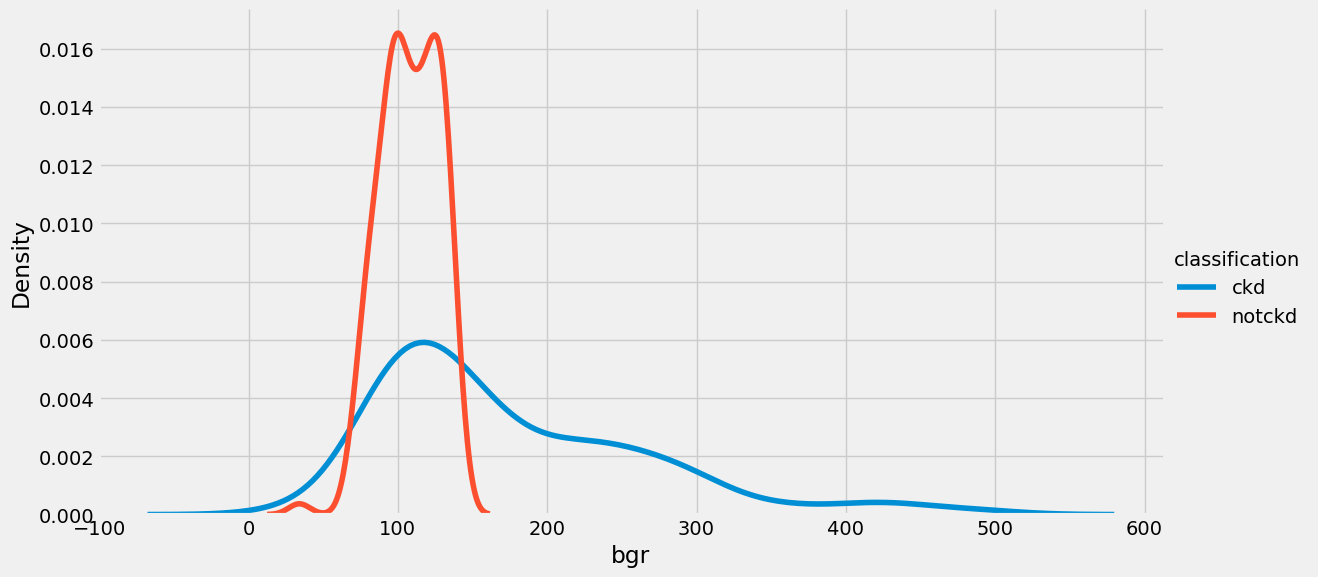

In [53]:
#('blood_glucose_random')
kde('bgr')

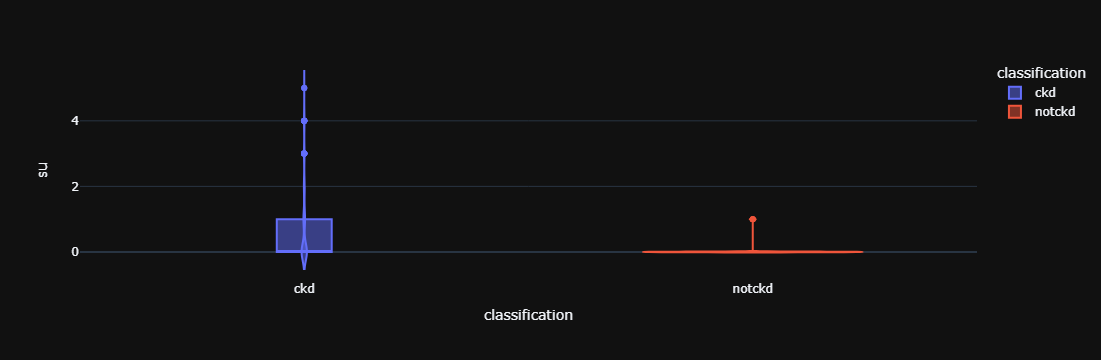

In [54]:
#sodium
violin('su')

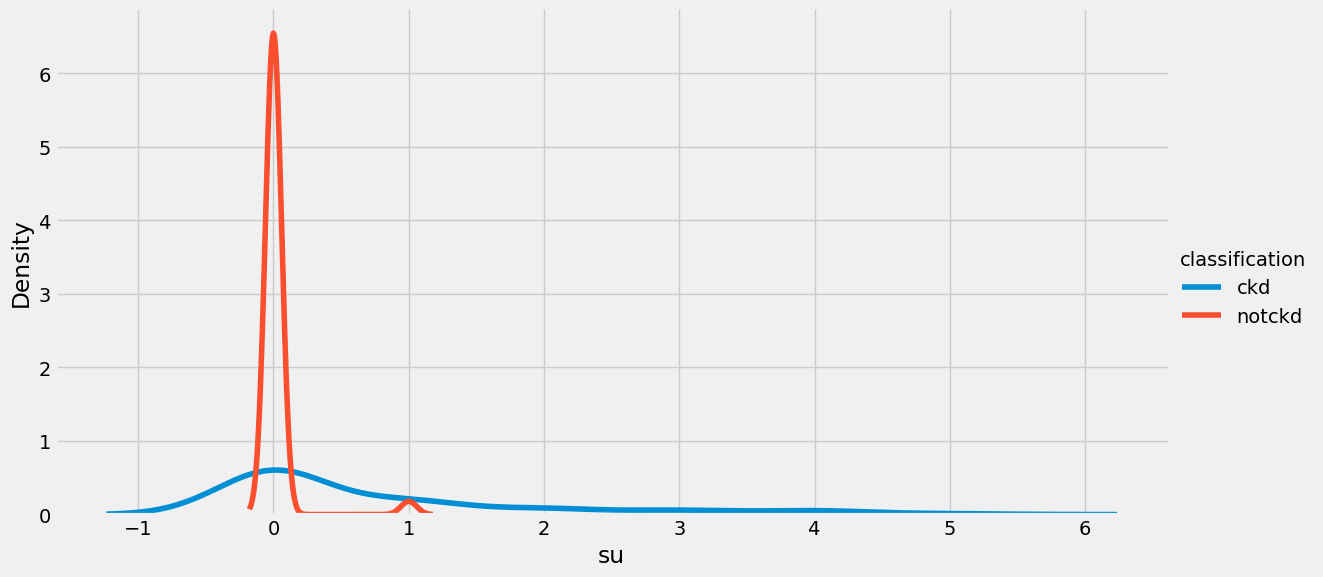

In [55]:
kde('su')

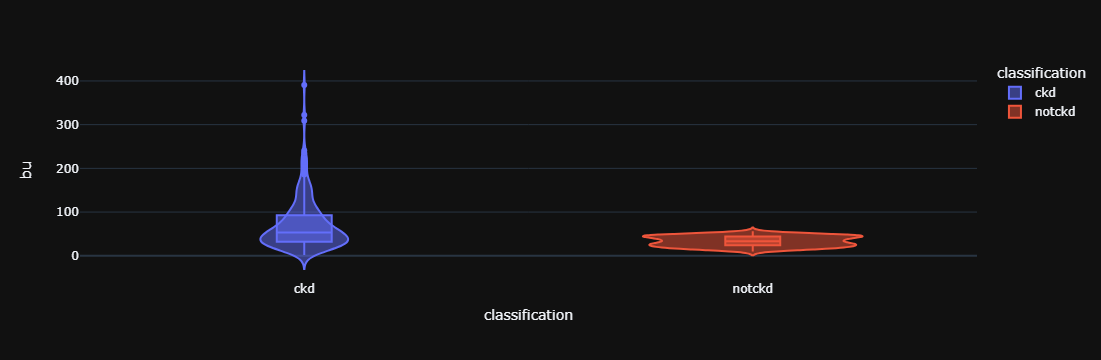

In [56]:
#violin('blood_urea')
violin('bu')

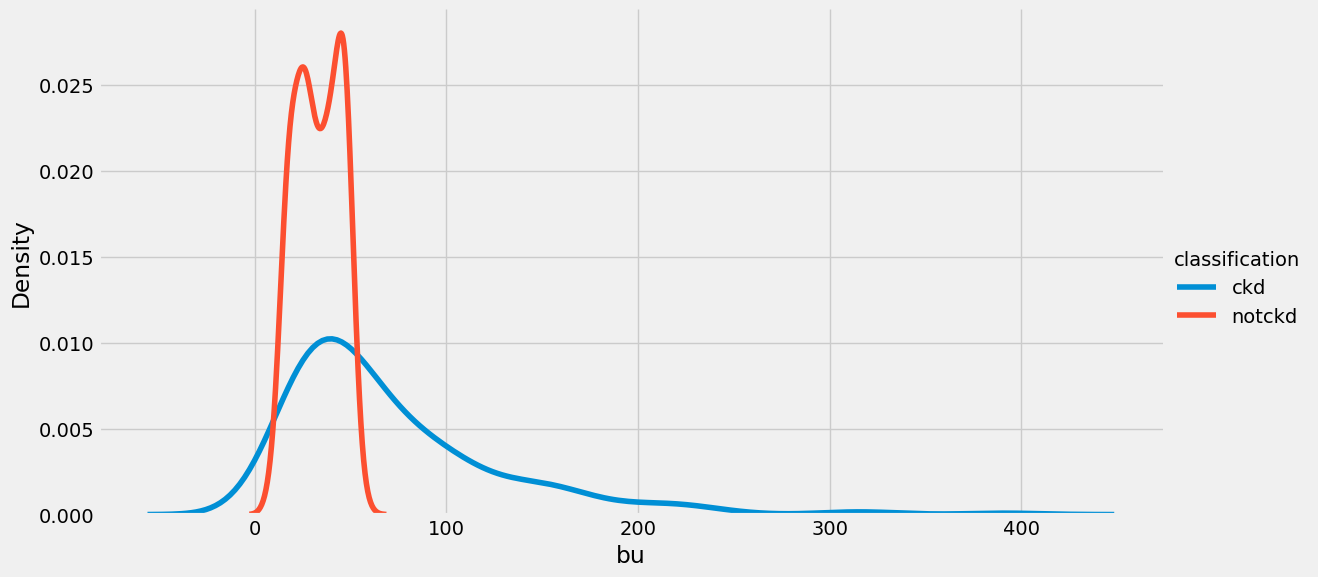

In [57]:
#kde('blood_urea')
kde('bu')

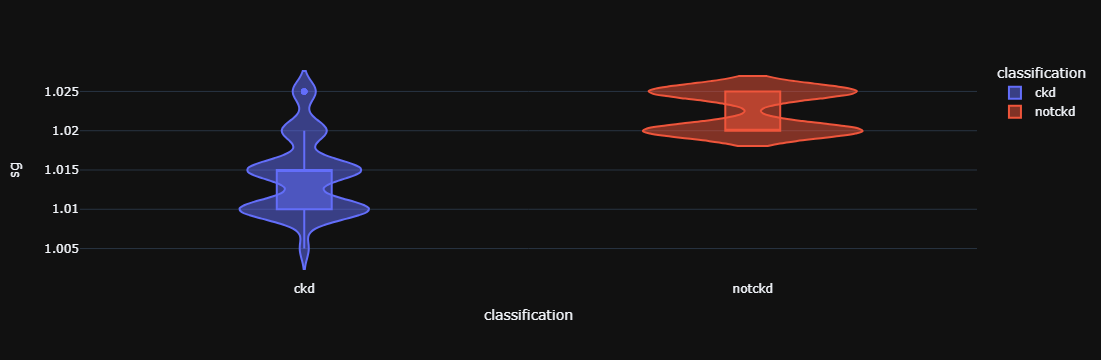

In [58]:
#violin('specific_gravity')
violin('sg')

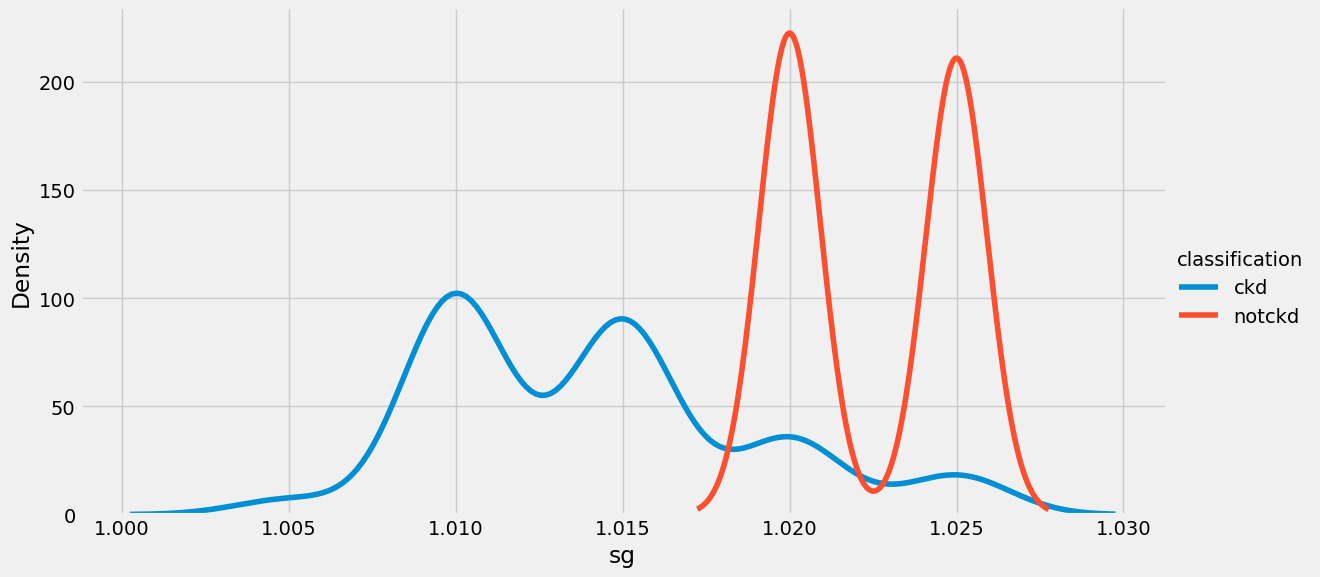

In [59]:
#kde('specific_gravity')
kde('sg')

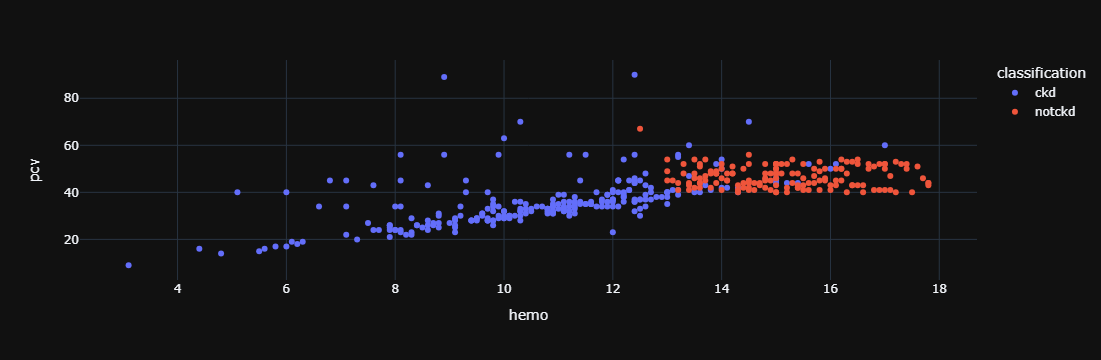

In [60]:
#scatter('haemoglobin', 'packed_cell_volume')
scatter('hemo', 'pcv')

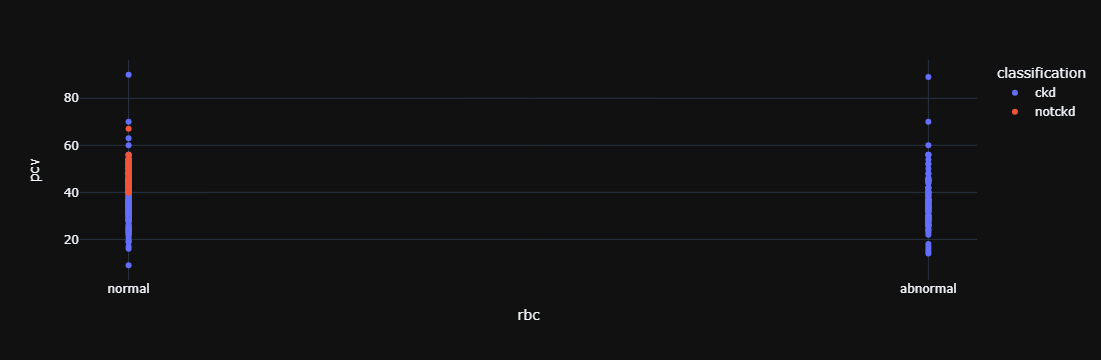

In [61]:
#scatter('red_blood_cell_count', 'packed_cell_volume')
scatter('rbc', 'pcv')

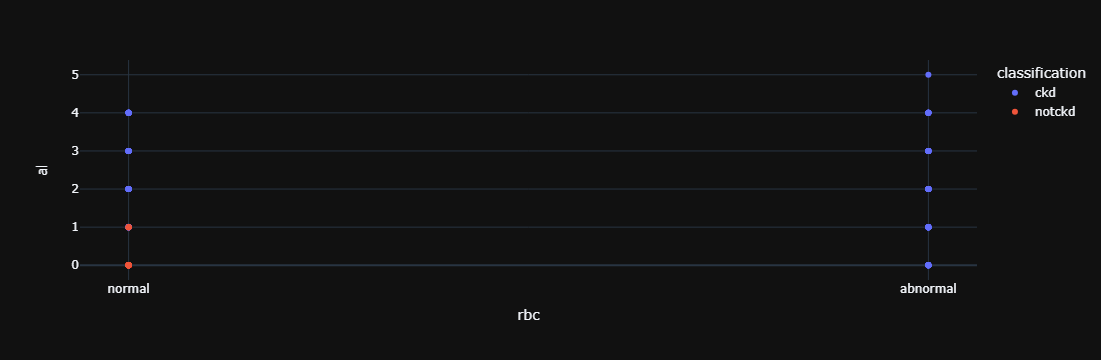

In [62]:
#scatter('red_blood_cell_count', 'albumin')
scatter('rbc', 'al')

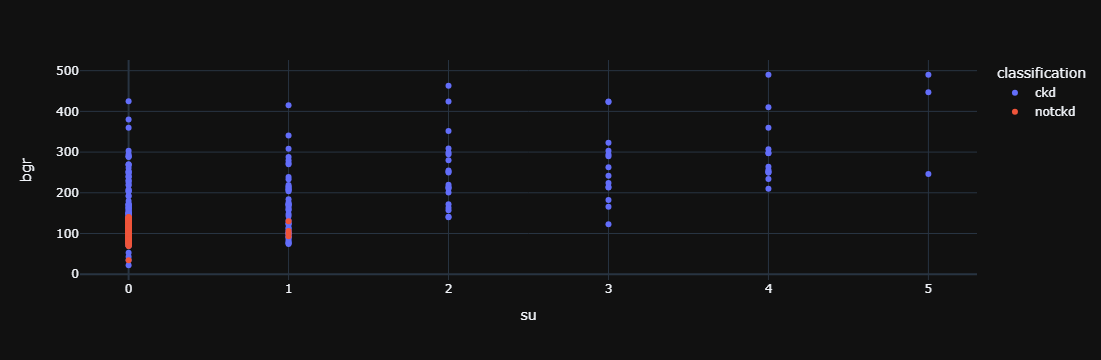

In [63]:
#scatter('sugar', 'blood_glucose_random')
scatter('su', 'bgr')

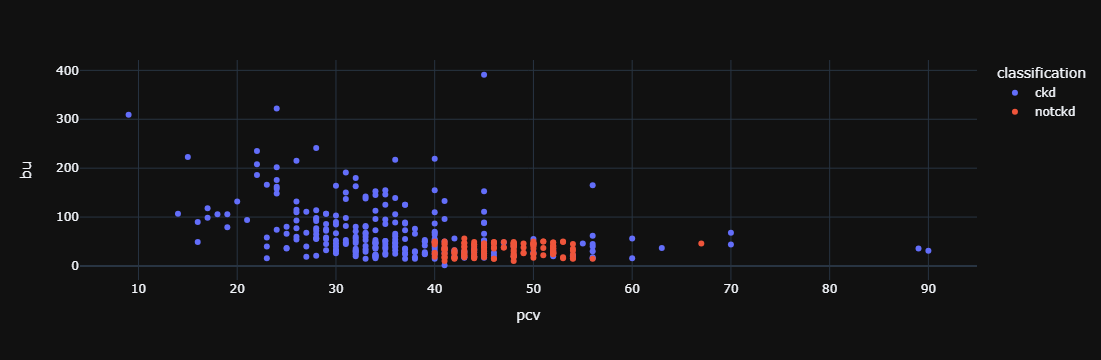

In [64]:
#scatter('packed_cell_volume','blood_urea')
scatter('pcv','bu')

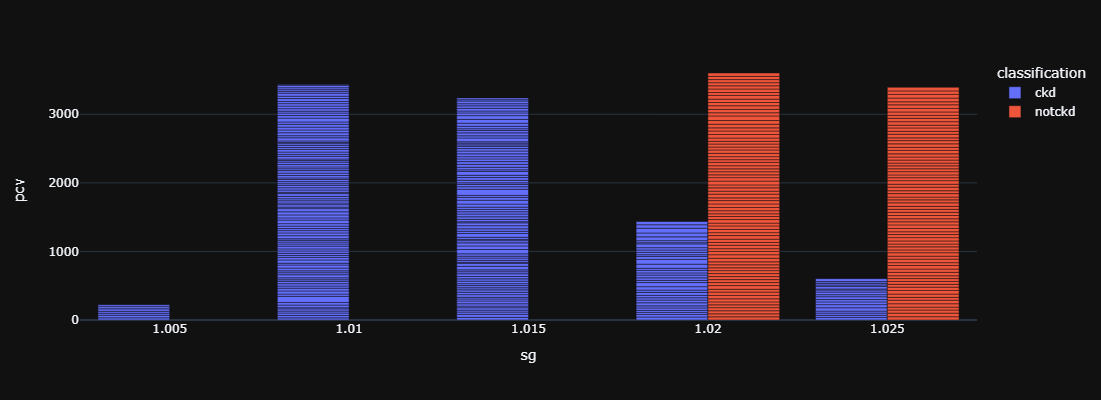

In [65]:
#px.bar(df, x="specific_gravity", y="packed_cell_volume", color='class', barmode='group', template = 'plotly_dark', height = 400)
px.bar(df, x="sg", y="pcv", color='classification', barmode='group', template = 'plotly_dark', height = 400)

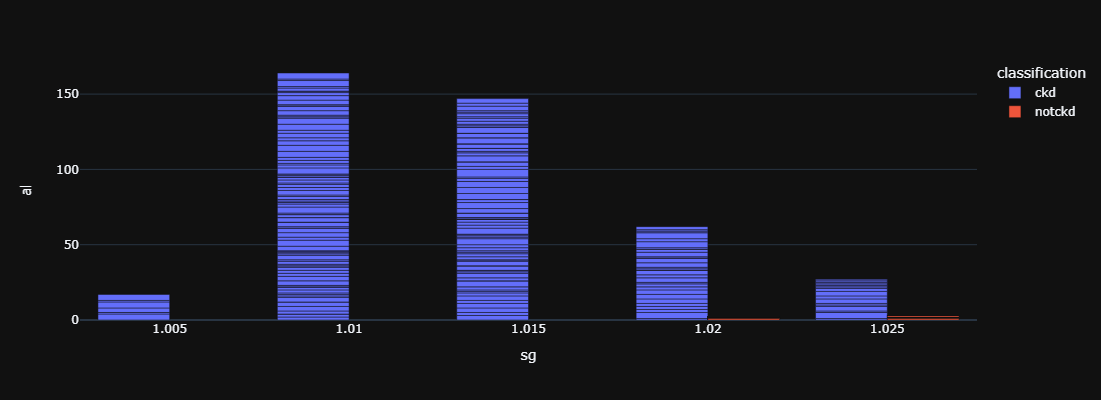

In [66]:
#df, x="specific_gravity", y="albumin", color='class', barmode='group', template = 'plotly_dark', height = 400)
px.bar(df, x="sg", y="al", color='classification', barmode='group', template = 'plotly_dark', height = 400)

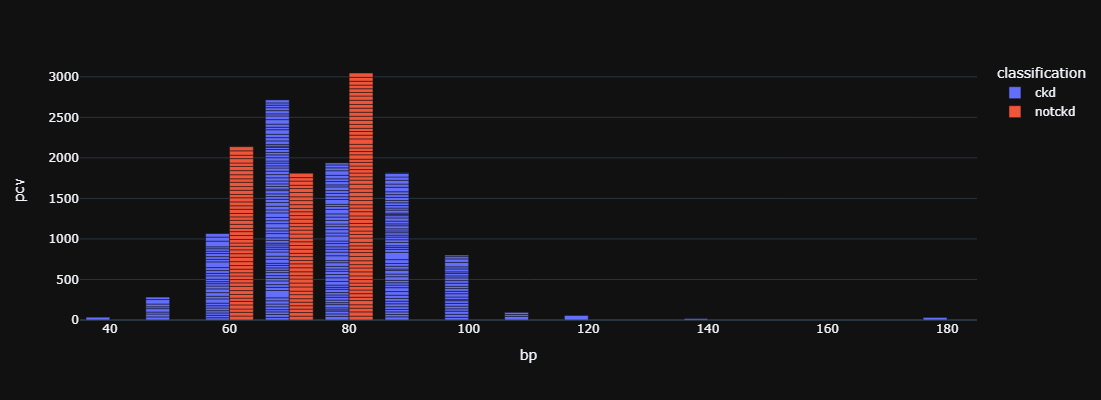

In [67]:
#df, x="blood_pressure", y="packed_cell_volume", color='class', barmode='group', template = 'plotly_dark', height = 400)
px.bar(df, x="bp", y="pcv", color='classification', barmode='group', template = 'plotly_dark', height = 400)

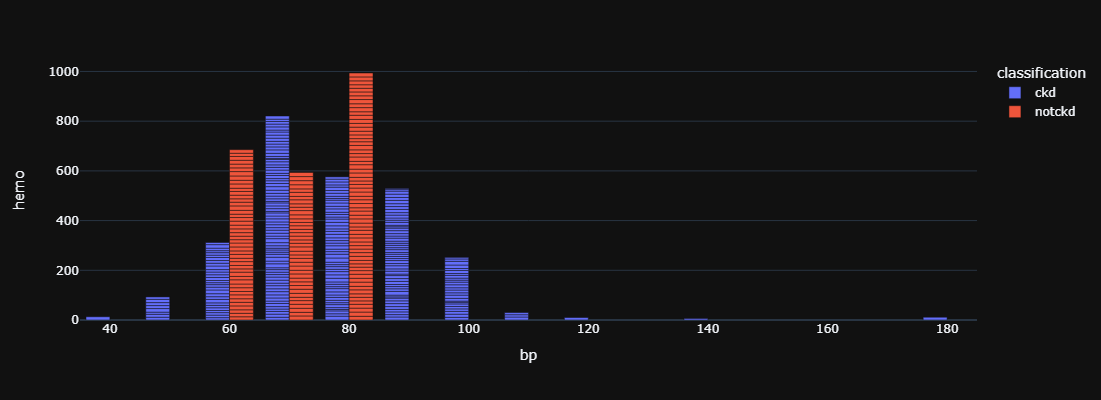

In [68]:
#df, x="blood_pressure", y="haemoglobin", color='class', barmode='group', template = 'plotly_dark', height = 400)
px.bar(df, x="bp", y="hemo", color='classification', barmode='group', template = 'plotly_dark', height = 400)

In [ ]:
#Data Pre Processing

In [69]:
# checking for null values

df.isna().sum().sort_values(ascending = False)

bp                2
su                1
id                0
pot               0
ane               0
pe                0
appet             0
cad               0
dm                0
htn               0
rc                0
wc                0
pcv               0
hemo              0
sod               0
age               0
sc                0
bu                0
bgr               0
ba                0
pcc               0
pc                0
rbc               0
al                0
sg                0
classification    0
dtype: int64

In [70]:
num_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']


In [71]:
df[num_cols].isnull().sum()


age     0
bp      2
sg      0
al      0
su      1
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wc      0
rc      0
dtype: int64

In [72]:
df[cat_cols].isnull().sum()

rbc               0
pc                0
pcc               0
ba                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [100]:
# filling null values, we will use two methods, random sampling for higher null values and 
# mean/mode sampling for lower null values

def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample
    
def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [101]:
# filling num_cols null values using random sampling method

for col in num_cols:
    random_value_imputation(col)

In [73]:
df[num_cols].isnull().sum()

age     0
bp      2
sg      0
al      0
su      1
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wc      0
rc      0
dtype: int64

In [76]:
df[cat_cols].isnull().sum()

rbc               0
pc                0
pcc               0
ba                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [ ]:
#All the missing values are handeled now, lets do ctaegorical features encding now




In [ ]:
#Feature Encoding


In [106]:
for col in cat_cols:
    print(f"{col} has {df[col].nunique()} categories\n")

rbc has 2 categories

pc has 2 categories

pcc has 2 categories

ba has 2 categories

htn has 2 categories

dm has 5 categories

cad has 3 categories

appet has 2 categories

pe has 2 categories

ane has 2 categories

classification has 3 categories



In [ ]:
#As all of the categorical columns have 2 categories we can use label encoder

In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [108]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48,80.0,1.020,1.0,0.0,1,1,0,0,121,36.0,1.2,130,3.3,15.4,44,7800,5.2,1,4,1,0,0,0,0
1,1,7,50.0,1.020,4.0,0.0,1,1,0,0,110,18.0,0.8,145,4.9,11.3,38,6000,4.3,0,3,1,0,0,0,0
2,2,62,80.0,1.010,2.0,3.0,1,1,0,0,423,53.0,1.8,150,6.1,9.6,31,7500,4.2,0,4,1,1,0,1,0
3,3,48,70.0,1.005,4.0,0.0,1,0,1,0,117,56.0,3.8,111,2.5,11.2,32,6700,3.9,1,3,1,1,1,1,0
4,4,51,80.0,1.010,2.0,0.0,1,1,0,0,106,26.0,1.4,121,3.5,11.6,35,7300,4.6,0,3,1,0,0,0,0


In [ ]:
#Model Building

In [111]:
ind_col = [col for col in df.columns if col != 'classification']
dep_col = 'classification'

X = df[ind_col]
y = df[dep_col]

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0, k_neighbors=1)  # <- lower k_neighbors
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.30, 
    random_state=0, 
    stratify=y_resampled
)


In [ ]:
#KNN

Best k value from GridSearchCV: 2
Training Accuracy of KNN is 1.0000
Test Accuracy of KNN is 0.9833 

Confusion Matrix :- 
[[73  2]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        75
           1       0.96      1.00      0.98        45

    accuracy                           0.98       120
   macro avg       0.98      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120

Cross-validation Accuracy: 0.9925 ± 0.0100


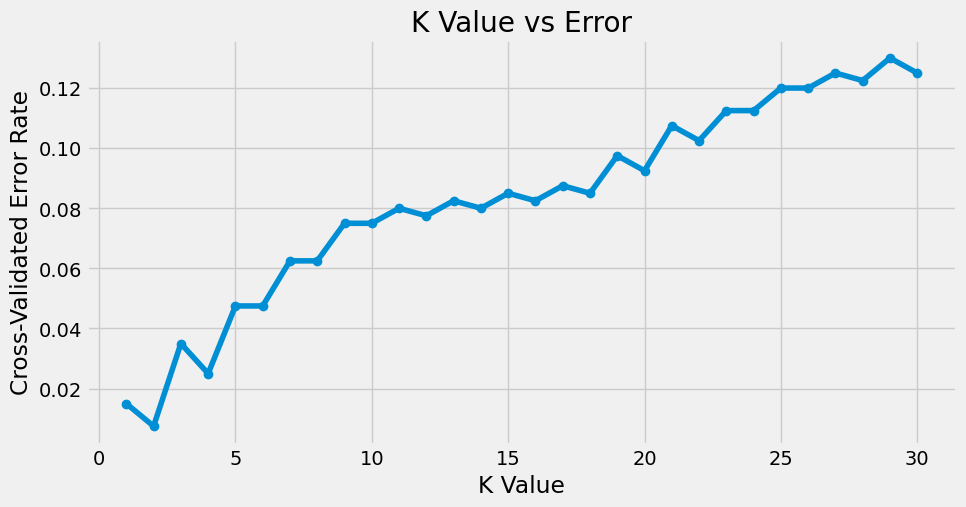

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load and clean the dataset
df = pd.read_csv("kidney_disease.csv")

df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

if 'id' in df.columns:
    df = df.drop('id', axis=1)

df = df.fillna(method='ffill')  # Simple missing value handling

# Encode categorical features
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

# Define X and y
X = df.drop('classification', axis=1)
y = df['classification']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce dimensionality
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.30, stratify=y, random_state=0
)

# Grid Search for best k
param_grid = {'n_neighbors': list(range(1, 31))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
best_k = grid.best_params_['n_neighbors']
print(f"Best k value from GridSearchCV: {best_k}")

# Train KNN with best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc = accuracy_score(y_test, knn.predict(X_test))
print(f"Training Accuracy of KNN is {train_acc:.4f}")
print(f"Test Accuracy of KNN is {test_acc:.4f} \n")
print(f"Confusion Matrix :- \n{confusion_matrix(y_test, knn.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, knn.predict(X_test))}")

# Cross-validation score
cv_scores = cross_val_score(knn, X_pca, y, cv=5)
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# K vs Error plot
error_rates = []
k_values = range(1, 31)
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_pca, y, cv=5)
    error_rates.append(1 - scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Error Rate')
plt.title('K Value vs Error')
plt.grid(True)
plt.show()

# Plotting functions for EDA
def count(col):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="classification")
    plt.title(f"Count of {col} by Classification")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def violin(col):
    fig = px.violin(df, y=col, x="classification", color="classification", box=True, template='plotly_dark')
    return fig.show()

def kde(col):
    grid = sns.FacetGrid(df, hue="classification", height=6, aspect=2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

def scatter(col1, col2):
    fig = px.scatter(df, x=col1, y=col2, color="classification", template='plotly_dark')
    return fig.show()


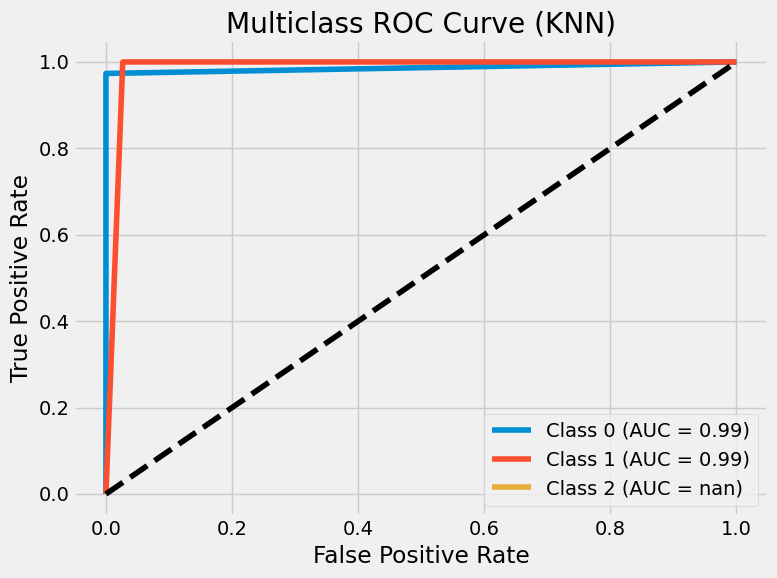

In [86]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (KNN)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


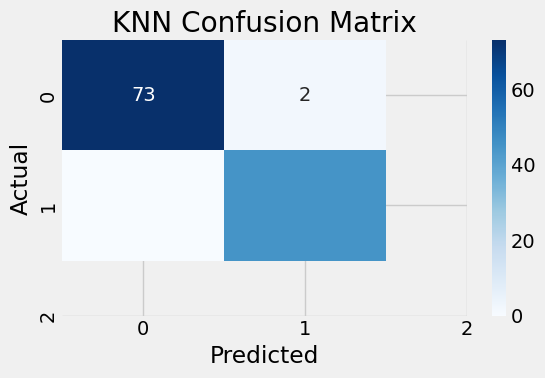

In [85]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
#Decision Tree Classifier

In [79]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of decision tree

dtc_acc = accuracy_score(y_test, dtc.predict(X_test))

print(f"Training Accuracy of Decision Tree Classifier is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Test Accuracy of Decision Tree Classifier is {dtc_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, dtc.predict(X_test))}")

Training Accuracy of Decision Tree Classifier is 1.0
Test Accuracy of Decision Tree Classifier is 0.9916666666666667 

Confusion Matrix :- 
[[74  1]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



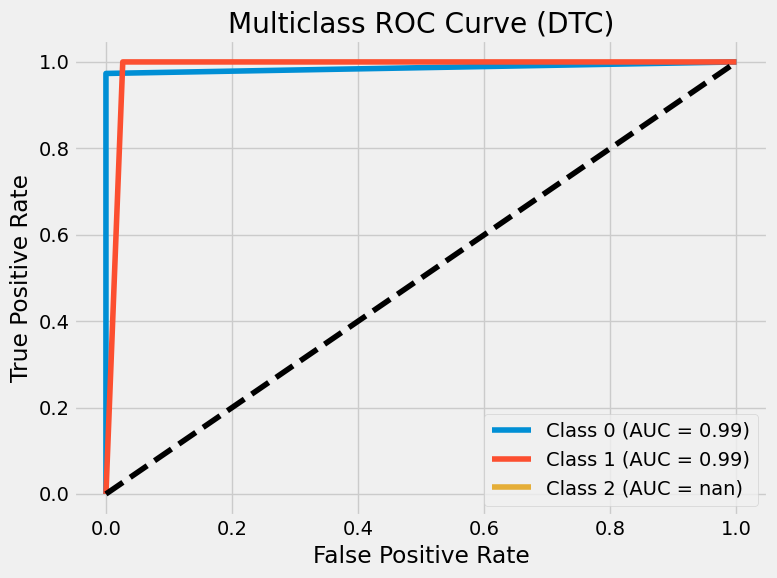

In [84]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (DTC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


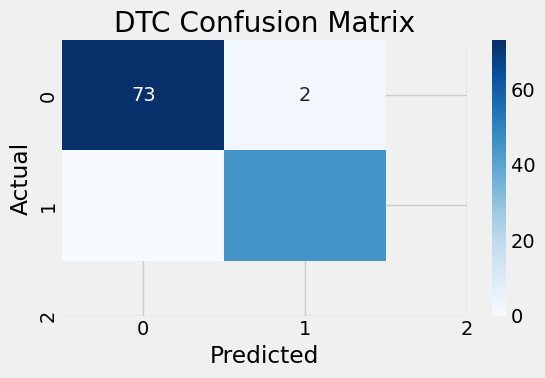

In [83]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("DTC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [115]:
# hyper parameter tuning of decision tree 

from sklearn.model_selection import GridSearchCV
grid_param = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [3, 5, 7, 10],
    'splitter' : ['best', 'random'],
    'min_samples_leaf' : [1, 2, 3, 5, 7],
    'min_samples_split' : [1, 2, 3, 5, 7],
    'max_features' : ['auto', 'sqrt', 'log2']
}

grid_search_dtc = GridSearchCV(dtc, grid_param, cv = 5, n_jobs = -1, verbose = 1)
grid_search_dtc.fit(X_train, y_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 5, 7],
                         'min_samples_split': [1, 2, 3, 5, 7],
                         'splitter': ['best', 'random']},
             verbose=1)

In [116]:
# best parameters and best score

print(grid_search_dtc.best_params_)
print(grid_search_dtc.best_score_)

{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 7, 'splitter': 'best'}
0.9964285714285713


Best k value from GridSearchCV: 2
Training Accuracy of KNN is 1.0000
Test Accuracy of KNN is 0.9833 

Confusion Matrix :- 
[[73  2]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        75
           1       0.96      1.00      0.98        45

    accuracy                           0.98       120
   macro avg       0.98      0.99      0.98       120
weighted avg       0.98      0.98      0.98       120

Cross-validation Accuracy: 0.9925 ± 0.0100


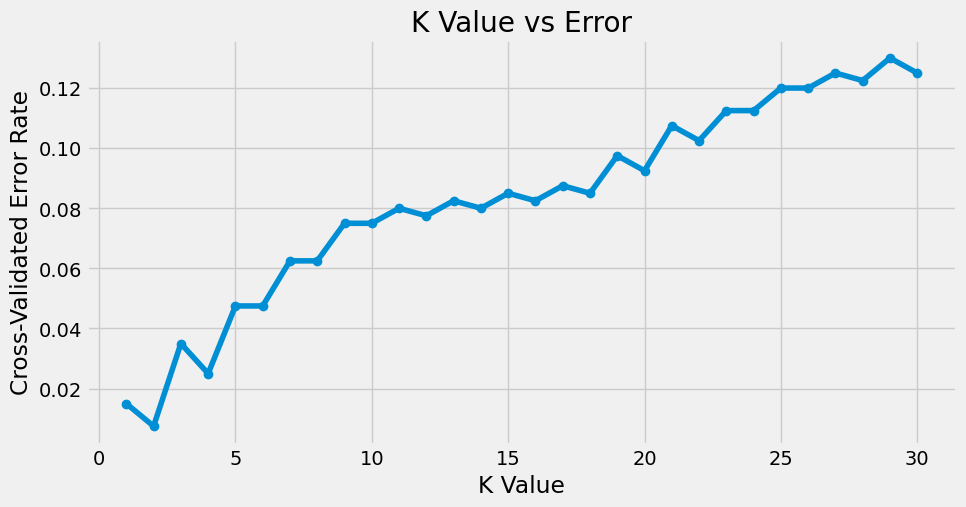

Training Accuracy of Decision Tree Classifier is 1.0
Test Accuracy of Decision Tree Classifier is 0.9916666666666667 

Confusion Matrix :- 
[[74  1]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load and clean dataset
df = pd.read_csv("kidney_disease.csv")

df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

if 'id' in df.columns:
    df = df.drop('id', axis=1)

df = df.fillna(method='ffill')  # Simple missing value handling

# Encode categorical features
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

# Define X and y
X = df.drop('classification', axis=1)
y = df['classification']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce dimensionality
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.30, stratify=y, random_state=0
)

# Grid Search for best k in KNN
param_grid = {'n_neighbors': list(range(1, 31))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
best_k = grid.best_params_['n_neighbors']
print(f"Best k value from GridSearchCV: {best_k}")

# Train KNN with best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Evaluate KNN
train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc = accuracy_score(y_test, knn.predict(X_test))
print(f"Training Accuracy of KNN is {train_acc:.4f}")
print(f"Test Accuracy of KNN is {test_acc:.4f} \n")
print(f"Confusion Matrix :- \n{confusion_matrix(y_test, knn.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, knn.predict(X_test))}")

# Cross-validation score for KNN
cv_scores = cross_val_score(knn, X_pca, y, cv=5)
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# K vs Error plot
error_rates = []
k_values = range(1, 31)
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_pca, y, cv=5)
    error_rates.append(1 - scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Error Rate')
plt.title('K Value vs Error')
plt.grid(True)
plt.show()

# Decision Tree Grid Search
dtc_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dtc = GridSearchCV(DecisionTreeClassifier(random_state=0), dtc_params, cv=5)
grid_search_dtc.fit(X_train, y_train)
dtc = grid_search_dtc.best_estimator_

# Evaluate Decision Tree
dtc_acc = accuracy_score(y_test, dtc.predict(X_test))
print(f"Training Accuracy of Decision Tree Classifier is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Test Accuracy of Decision Tree Classifier is {dtc_acc} \n")
print(f"Confusion Matrix :- \n{confusion_matrix(y_test, dtc.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, dtc.predict(X_test))}")

# Plotting functions for EDA
def count(col):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue="classification")
    plt.title(f"Count of {col} by Classification")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def violin(col):
    fig = px.violin(df, y=col, x="classification", color="classification", box=True, template='plotly_dark')
    return fig.show()

def kde(col):
    grid = sns.FacetGrid(df, hue="classification", height=6, aspect=2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

def scatter(col1, col2):
    fig = px.scatter(df, x=col1, y=col2, color="classification", template='plotly_dark')
    return fig.show()


In [ ]:
#Random Forest Classifier

In [81]:
from sklearn.ensemble import RandomForestClassifier

rd_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 11, max_features = 'auto', min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rd_clf.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of random forest

rd_clf_acc = accuracy_score(y_test, rd_clf.predict(X_test))

print(f"Training Accuracy of Random Forest Classifier is {accuracy_score(y_train, rd_clf.predict(X_train))}")
print(f"Test Accuracy of Random Forest Classifier is {rd_clf_acc} \n")
print(f"Confusion Matrix :- \n{confusion_matrix(y_test, rd_clf.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, rd_clf.predict(X_test))}")

Training Accuracy of Random Forest Classifier is 1.0
Test Accuracy of Random Forest Classifier is 0.9916666666666667 

Confusion Matrix :- 
[[74  1]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



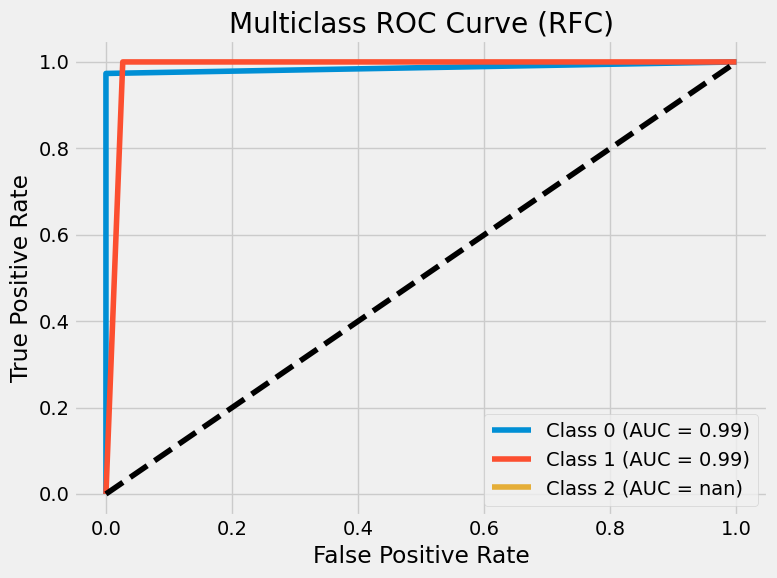

In [82]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (RFC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

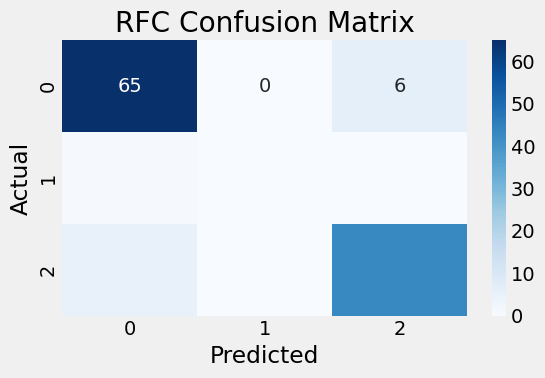

In [140]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("RFC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
#Ada Boost Classifier

In [88]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(base_estimator = dtc)
ada.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of ada boost

ada_acc = accuracy_score(y_test, ada.predict(X_test))

print(f"Training Accuracy of Ada Boost Classifier is {accuracy_score(y_train, ada.predict(X_train))}")
print(f"Test Accuracy of Ada Boost Classifier is {ada_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, ada.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, ada.predict(X_test))}")

Training Accuracy of Ada Boost Classifier is 1.0
Test Accuracy of Ada Boost Classifier is 0.9833333333333333 

Confusion Matrix :- 
[[74  1]
 [ 1 44]]

Classification Report :- 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        75
           1       0.98      0.98      0.98        45

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



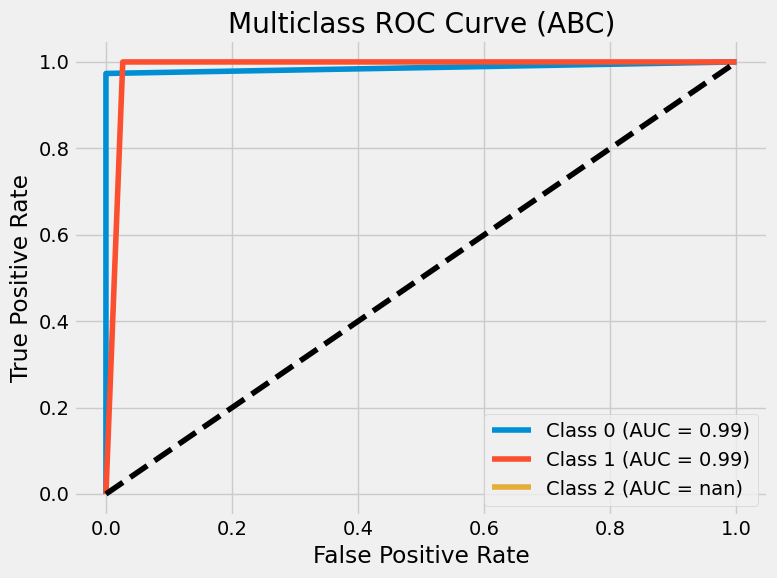

In [89]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (ABC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

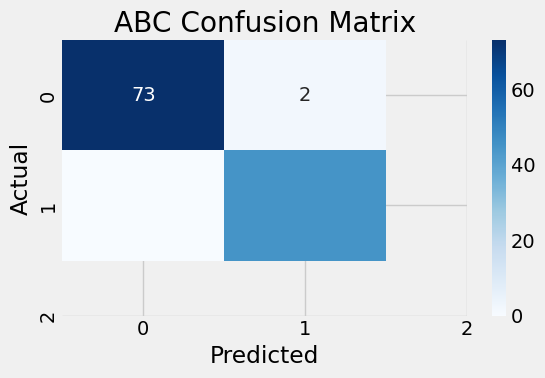

In [90]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("ABC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
#Gradient Boosting Classifier

In [91]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of gradient boosting classifier

gb_acc = accuracy_score(y_test, gb.predict(X_test))

print(f"Training Accuracy of Gradient Boosting Classifier is {accuracy_score(y_train, gb.predict(X_train))}")
print(f"Test Accuracy of Gradient Boosting Classifier is {gb_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, gb.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, gb.predict(X_test))}")

Training Accuracy of Gradient Boosting Classifier is 1.0
Test Accuracy of Gradient Boosting Classifier is 0.9916666666666667 

Confusion Matrix :- 
[[74  1]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



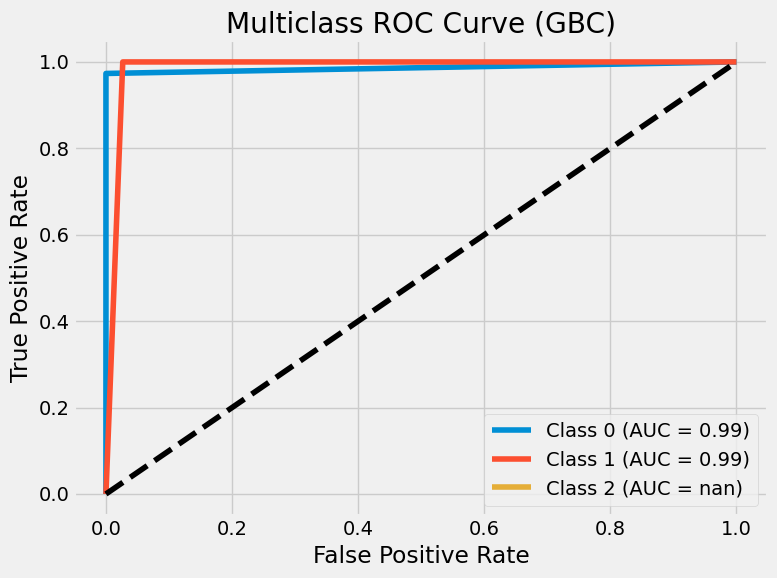

In [92]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (GBC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

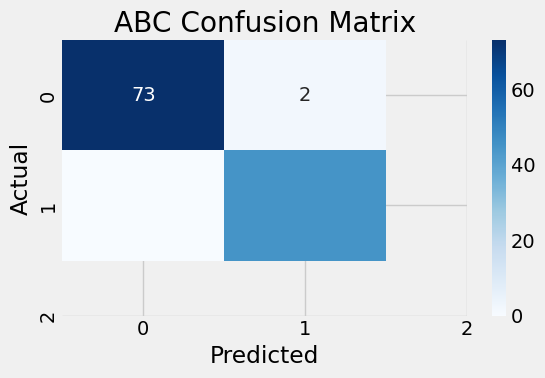

In [93]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("ABC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
#Stochastic Gradient Boosting (SGB)

In [94]:
sgb = GradientBoostingClassifier(max_depth = 4, subsample = 0.90, max_features = 0.75, n_estimators = 200)
sgb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of stochastic gradient boosting classifier

sgb_acc = accuracy_score(y_test, sgb.predict(X_test))

print(f"Training Accuracy of Stochastic Gradient Boosting is {accuracy_score(y_train, sgb.predict(X_train))}")
print(f"Test Accuracy of Stochastic Gradient Boosting is {sgb_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, sgb.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, sgb.predict(X_test))}")

Training Accuracy of Stochastic Gradient Boosting is 1.0
Test Accuracy of Stochastic Gradient Boosting is 0.9916666666666667 

Confusion Matrix :- 
[[74  1]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.98      1.00      0.99        45

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



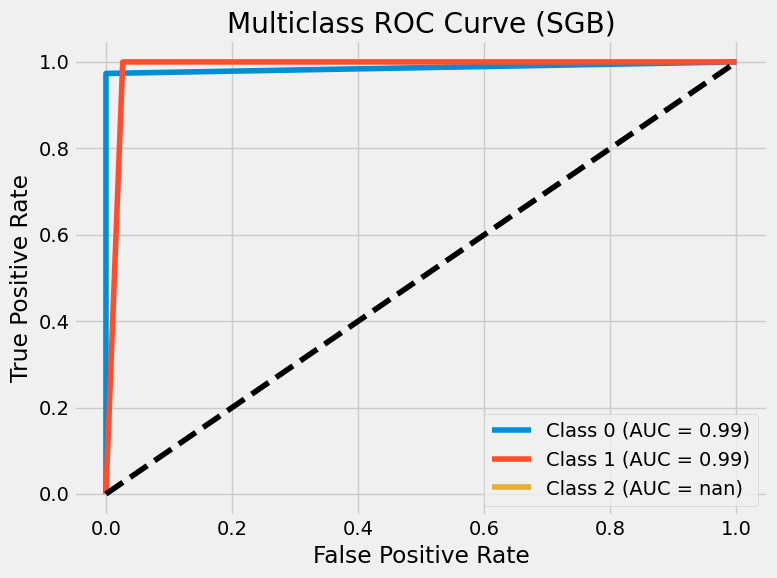

In [95]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (SGB)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

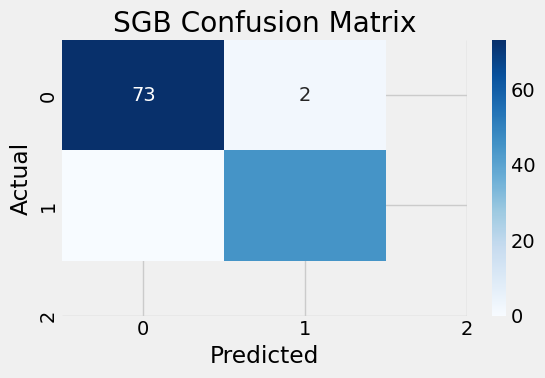

In [96]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("SGB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [127]:
#Extra Trees Classifier

In [97]:
from sklearn.ensemble import ExtraTreesClassifier

etc = ExtraTreesClassifier()
etc.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of extra trees classifier

etc_acc = accuracy_score(y_test, etc.predict(X_test))

print(f"Training Accuracy of Extra Trees Classifier is {accuracy_score(y_train, etc.predict(X_train))}")
print(f"Test Accuracy of Extra Trees Classifier is {etc_acc} \n")

print(f"Confusion Matrix :- \n{confusion_matrix(y_test, etc.predict(X_test))}\n")
print(f"Classification Report :- \n {classification_report(y_test, etc.predict(X_test))}")

Training Accuracy of Extra Trees Classifier is 1.0
Test Accuracy of Extra Trees Classifier is 1.0 

Confusion Matrix :- 
[[75  0]
 [ 0 45]]

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        45

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



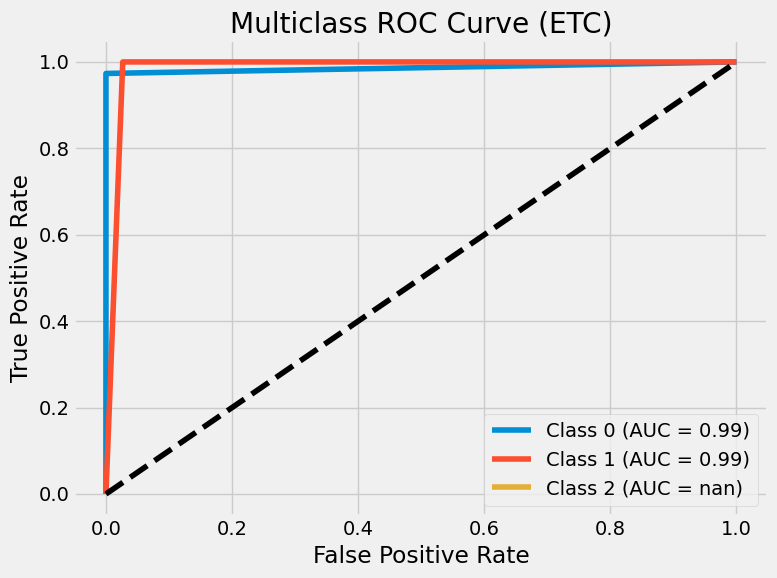

In [98]:
#ROC Curve (for multiclass with OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize target
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Fit classifier with OneVsRest strategy
ovr_knn = OneVsRestClassifier(knn)
ovr_knn.fit(X_train, label_binarize(y_train, classes=[0, 1, 2]))
y_score = ovr_knn.predict_proba(X_test)

# Plot ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curve (ETC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

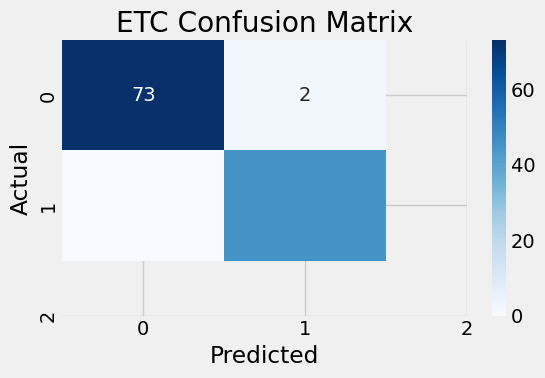

In [99]:
#Confusion Matrix (Visual Plot)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("ETC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()